## Assignment 6: More Matplotlib

#### Problem 1

In [76]:
import numpy as np
from matplotlib import pyplot as plt

In [77]:
import pooch
POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    # Use the figshare DOI
    base_url="doi:10.5281/zenodo.5553029/",
    registry={
        "HEADERS.txt": "md5:2a306ca225fe3ccb72a98953ded2f536",
        "CRND0103-2016-NY_Millbrook_3_W.txt": "md5:eb69811d14d0573ffa69f70dd9c768d9",
        "CRND0103-2017-NY_Millbrook_3_W.txt": "md5:b911da727ba1bdf26a34a775f25d1088",
        "CRND0103-2018-NY_Millbrook_3_W.txt": "md5:5b61bc687261596eba83801d7080dc56",
        "CRND0103-2019-NY_Millbrook_3_W.txt": "md5:9b814430612cd8a770b72020ca4f2b7d",
        "CRND0103-2020-NY_Millbrook_3_W.txt": "md5:cd8de6d5445024ce35fcaafa9b0e7b64"
    },
)


import pandas as pd

with open(POOCH.fetch("HEADERS.txt")) as fp:
    data = fp.read()
lines = data.split('\n')
headers = lines[1].split(' ')

dframes = []
for year in range(2016, 2019):
    fname = f'CRND0103-{year}-NY_Millbrook_3_W.txt'               
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep='\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')
df

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays)  
#### NO PANDAS ALLOWED!
#########################################################

t_daily_min = df.T_DAILY_MIN.values
t_daily_max = df.T_DAILY_MAX.values
t_daily_mean = df.T_DAILY_MEAN.values
p_daily_calc = df.P_DAILY_CALC.values
soil_moisture_5 = df.SOIL_MOISTURE_5_DAILY.values
soil_moisture_10 = df.SOIL_MOISTURE_10_DAILY.values
soil_moisture_20 = df.SOIL_MOISTURE_20_DAILY.values
soil_moisture_50 = df.SOIL_MOISTURE_50_DAILY.values
soil_moisture_100 = df.SOIL_MOISTURE_100_DAILY.values
date = df.index.values

In [78]:
units = lines[2].split(' ')
for name, unit in zip(headers, units):
    print(f'{name}: {unit}')

WBANNO: XXXXX
LST_DATE: YYYYMMDD
CRX_VN: XXXXXX
LONGITUDE: Decimal_degrees
LATITUDE: Decimal_degrees
T_DAILY_MAX: Celsius
T_DAILY_MIN: Celsius
T_DAILY_MEAN: Celsius
T_DAILY_AVG: Celsius
P_DAILY_CALC: mm
SOLARAD_DAILY: MJ/m^2
SUR_TEMP_DAILY_TYPE: X
SUR_TEMP_DAILY_MAX: Celsius
SUR_TEMP_DAILY_MIN: Celsius
SUR_TEMP_DAILY_AVG: Celsius
RH_DAILY_MAX: %
RH_DAILY_MIN: %
RH_DAILY_AVG: %
SOIL_MOISTURE_5_DAILY: m^3/m^3
SOIL_MOISTURE_10_DAILY: m^3/m^3
SOIL_MOISTURE_20_DAILY: m^3/m^3
SOIL_MOISTURE_50_DAILY: m^3/m^3
SOIL_MOISTURE_100_DAILY: m^3/m^3
SOIL_TEMP_5_DAILY: Celsius
SOIL_TEMP_10_DAILY: Celsius
SOIL_TEMP_20_DAILY: Celsius
SOIL_TEMP_50_DAILY: Celsius
SOIL_TEMP_100_DAILY: Celsius
: 


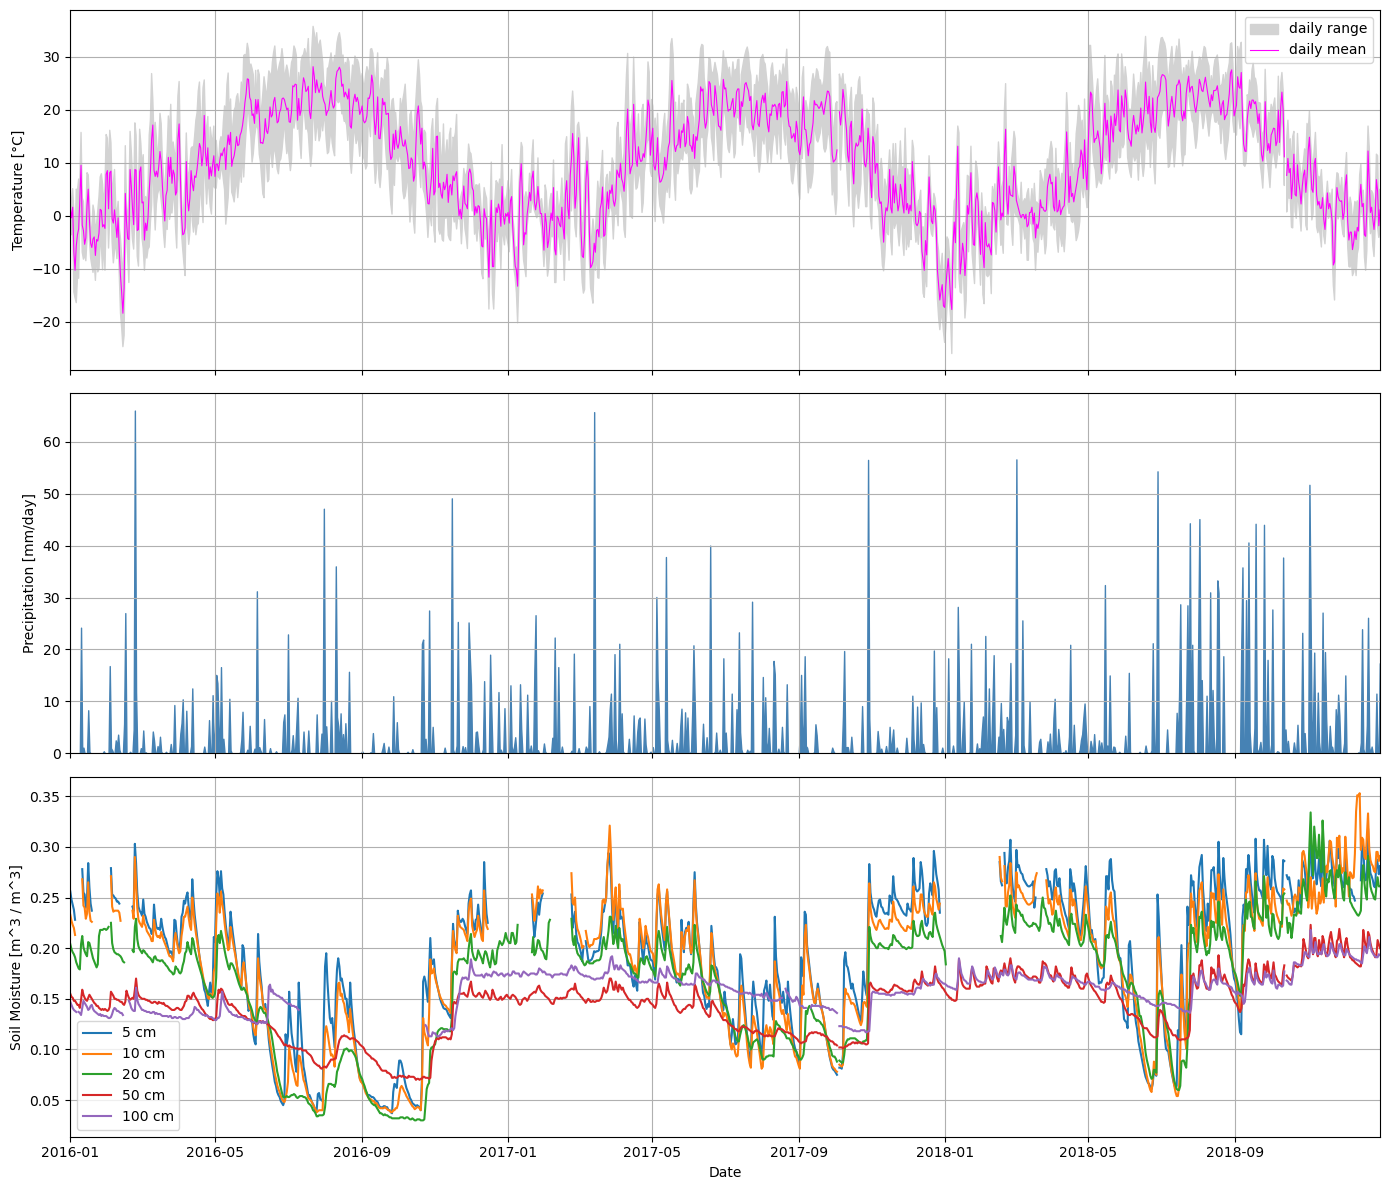

In [79]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 12), sharex=True)

#Temp
axes[0].fill_between(date, t_daily_min, t_daily_max, color='lightgrey', label='daily range')
axes[0].plot(date, t_daily_mean, color='magenta', linewidth=0.8, label='daily mean')
axes[0].set_ylabel('Temperature [°C]')
axes[0].legend(loc='upper right')

#Precipitation
axes[1].bar(date, np.nan_to_num(p_daily_calc), color='steelblue', width=1)
axes[1].set_ylabel('Precipitation [mm/day]')
axes[1].fill_between(date, np.nan_to_num(p_daily_calc), color='steelblue')

#Soil Moisture
axes[2].plot(date, soil_moisture_5,   label='5 cm')
axes[2].plot(date, soil_moisture_10,  label='10 cm')
axes[2].plot(date, soil_moisture_20,  label='20 cm')
axes[2].plot(date, soil_moisture_50,  label='50 cm')
axes[2].plot(date, soil_moisture_100, label='100 cm')
axes[2].set_ylabel('Soil Moisture [m^3 / m^3]')
axes[2].legend(loc='lower left')

# xasxis label
axes[2].set_xlabel('Date')

axes[0].grid(True)
axes[1].grid(True)
axes[2].grid(True)
axes[2].set_xlim(date[0], date[-1])

fig.tight_layout()
plt.show()

#### Problem 2

In [80]:
import xarray as xr
ds_url = 'http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods'
ds = xr.open_dataset(ds_url, decode_times=False)

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays) 
#### NO XARRAY ALLOWED!
#########################################################

temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values

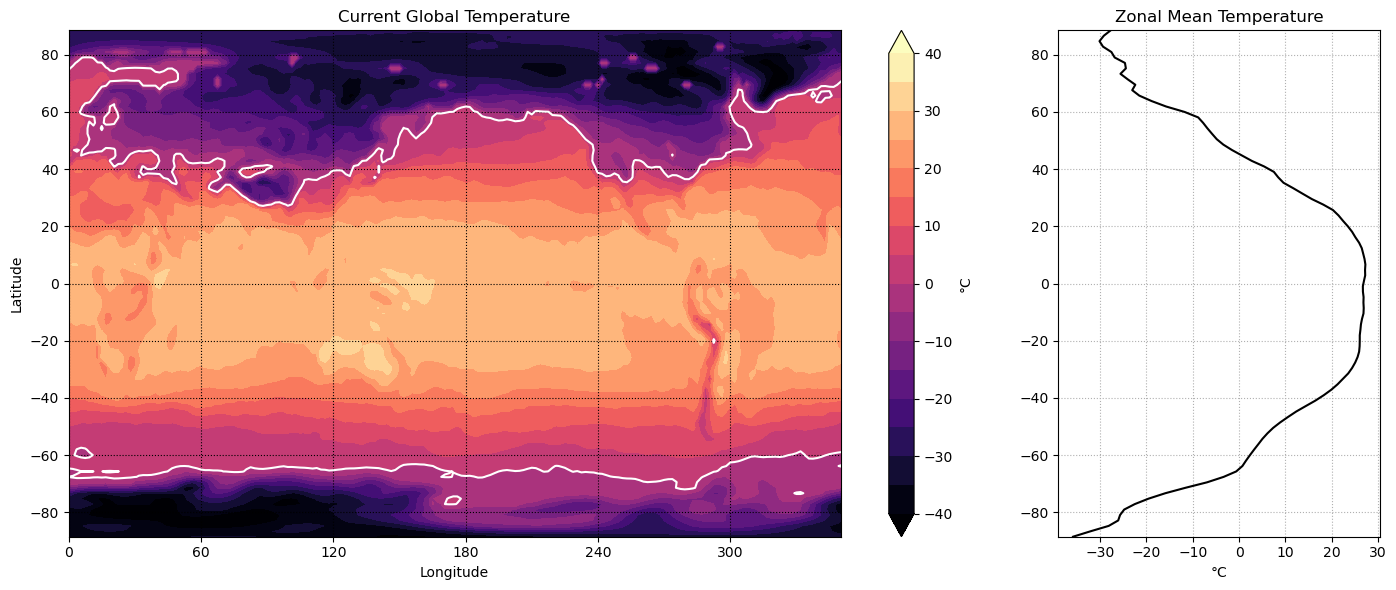

In [81]:
temp_zonal_mean = np.nanmean(temp, axis=1)
clevels = np.arange(-40, 45, 5)

fig, axes = plt.subplots(ncols=2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1]})

# Global Map
cf = axes[0].contourf(lon, lat, temp, clevels, cmap='magma', extend='both')
axes[0].contour(lon, lat, temp, [0], colors='white')
fig.colorbar(cf, ax=axes[0], label='°C')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Current Global Temperature')
axes[0].grid(linestyle='dotted', color='k')
axes[0].set_xlim(0, 350)
axes[0].set_xticks([0, 60, 120, 180, 240, 300])

# Zonal Mean
axes[1].plot(temp_zonal_mean, lat, color='k')
axes[1].set_xlabel('°C')
axes[1].set_title('Zonal Mean Temperature')
axes[1].grid(linestyle='dotted')
axes[1].set_ylim(lat.min(), lat.max())

fig.tight_layout()
plt.show()

#### Problem 3

In [82]:
fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

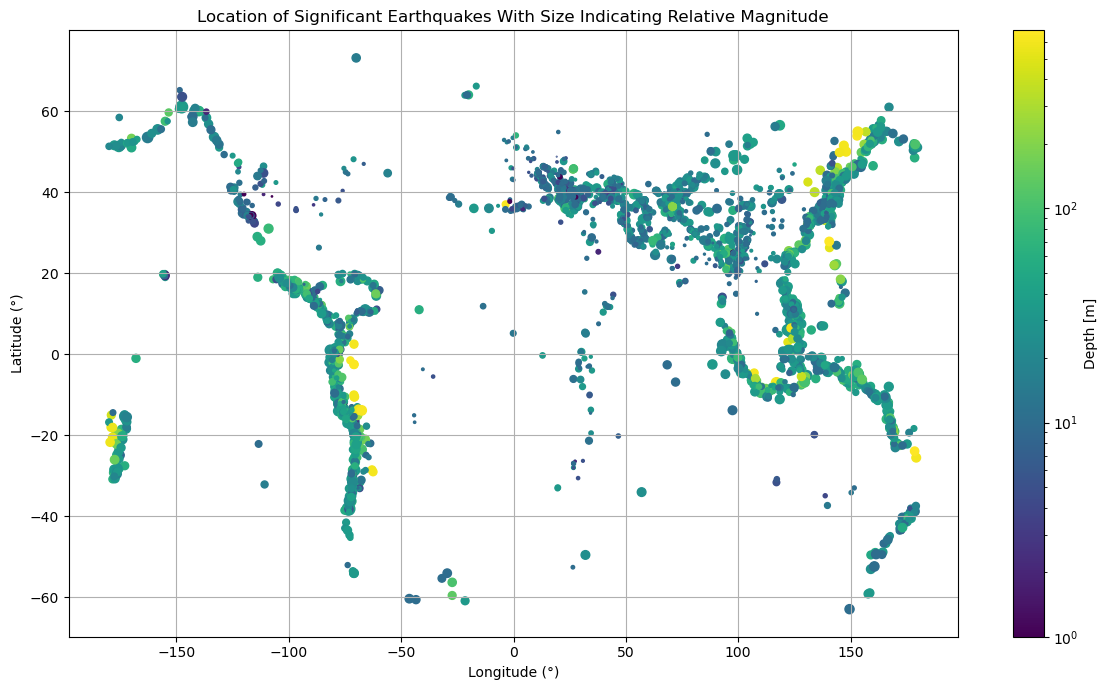

In [73]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(12, 7))

splot = ax.scatter(
    lon_v, lat_v,
    c=depth_v,
    s=magnitude_v**4 / 100,
    cmap='viridis',
    norm=LogNorm()
)

fig.colorbar(splot, ax=ax, label='Depth [m]')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title('Location of Significant Earthquakes With Size Indicating Relative Magnitude')
ax.grid(True)

plt.tight_layout()
plt.show()